In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv('../../outputs/df_engineered.csv', 
                  index_col='datetime', 
                  parse_dates=True)

In [4]:
data.columns

Index(['Temperature', 'Relative Humidity', 'Pressure', 'GHI',
       'Solar Zenith Angle', 'solar_zenith', 'solar_elevation',
       'ET_irradiance', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month',
       'week_of_year', 'day_of_week', 'GHI_lag_1h', 'GHI_lag_3h',
       'GHI_lag_24h', 'temp_lag_1h', 'temp_lag_3h', 'temp_lag_24h',
       'humidity_lag_1h', 'humidity_lag_3h', 'humidity_lag_24h',
       'GHI_rollmean_3h', 'GHI_rollmean_6h', 'GHI_rollmean_24h',
       'GHI_rollstd_3h', 'GHI_rollstd_6h', 'GHI_rollstd_24h',
       'cloud_cover_proxy', 'cloud_x_elevation', 'humidity_x_temp'],
      dtype='object')

In [6]:
data.shape

(8736, 33)

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,8736.0,1.351423e+01,9.179895,-4.800000,6.300000,1.220000e+01,19.900000,39.100000
Relative Humidity,8736.0,6.448296e+01,25.681762,6.510000,43.560000,6.640500e+01,88.012500,100.000000
Pressure,8736.0,9.104106e+02,5.338825,887.000000,907.000000,9.110000e+02,914.000000,923.000000
GHI,8736.0,1.838666e+02,277.334918,0.000000,0.000000,0.000000e+00,323.250000,1031.000000
Solar Zenith Angle,8736.0,8.961240e+01,35.644269,17.650000,62.097500,8.916000e+01,117.312500,162.260000
solar_zenith,8736.0,8.961224e+01,35.644469,17.652544,62.096450,8.915648e+01,117.313572,162.255077
solar_elevation,8736.0,3.877626e-01,35.644469,-72.255077,-27.313572,8.435183e-01,27.903550,72.347456
ET_irradiance,8736.0,3.266501e+02,409.126990,0.000000,0.000000,2.014391e+01,642.318256,1259.616397
hour_sin,8736.0,-8.946852e-18,0.707147,-1.000000,-0.707107,6.123234e-17,0.707107,1.000000
hour_cos,8736.0,-5.530781e-17,0.707147,-1.000000,-0.707107,-6.123234e-17,0.707107,1.000000


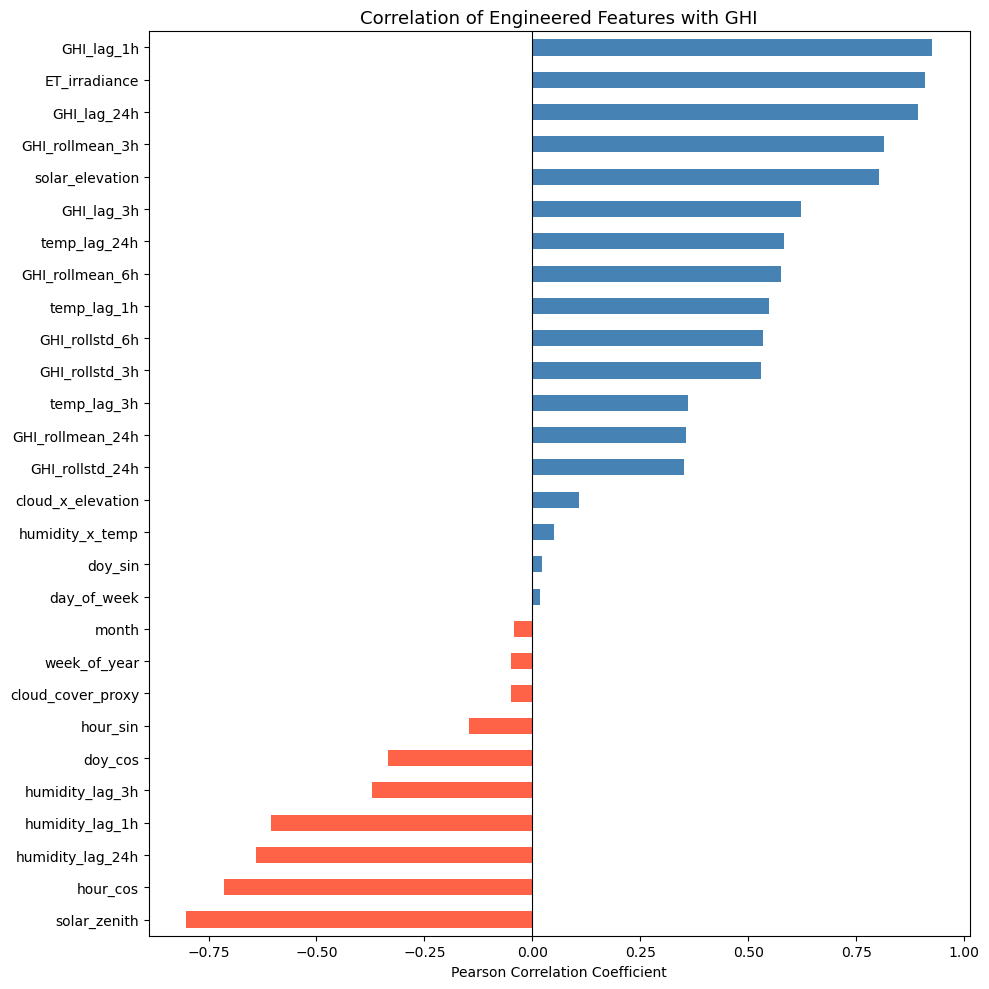

Top 5 positive correlations with GHI:
solar_elevation    0.802
GHI_rollmean_3h    0.814
GHI_lag_24h        0.893
ET_irradiance      0.910
GHI_lag_1h         0.926

Top 5 negative correlations with GHI:
solar_zenith       -0.802
hour_cos           -0.713
humidity_lag_24h   -0.639
humidity_lag_1h    -0.605
humidity_lag_3h    -0.372


In [14]:
import matplotlib.pyplot as plt

# Correlation of each engineered feature with GHI only
cols_engineered = [
    # Task 1 - Solar geometry (3 features)
    'solar_zenith', 
    'solar_elevation', 
    'ET_irradiance',

    # Task 2 - Time features (7 features)
    'hour_sin', 
    'hour_cos', 
    'doy_sin', 
    'doy_cos', 
    'month',
    'week_of_year',
    'day_of_week',

    # Task 3 - Lag features (9 features)
    'GHI_lag_1h', 
    'GHI_lag_3h', 
    'GHI_lag_24h',
    'temp_lag_1h', 
    'temp_lag_3h', 
    'temp_lag_24h',
    'humidity_lag_1h', 
    'humidity_lag_3h', 
    'humidity_lag_24h',

    # Task 4 - Rolling stats (6 features)
    'GHI_rollmean_3h', 
    'GHI_rollmean_6h', 
    'GHI_rollmean_24h',
    'GHI_rollstd_3h',  
    'GHI_rollstd_6h',  
    'GHI_rollstd_24h',

    # Task 5 - Interactions (3 features)
    'cloud_cover_proxy', 
    'cloud_x_elevation', 
    'humidity_x_temp'
]
corr_with_ghi = data[cols_engineered + ['GHI']].corr()['GHI'].drop('GHI').sort_values()

plt.figure(figsize=(10, 10))
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_with_ghi.values]
corr_with_ghi.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlation of Engineered Features with GHI', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../../Outputs/correlation_with_ghi.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 positive correlations with GHI:')
print(corr_with_ghi.tail(5).round(3).to_string())
print('\nTop 5 negative correlations with GHI:')
print(corr_with_ghi.head(5).round(3).to_string())

In [16]:
# Define a function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Created a new column 'Season' by applying the mapping function
data['Season'] = data.index.month.map(get_season)

# Group by 'Season' and sum the GHI values
seasonal_ghi_df = data.groupby('Season')['GHI'].mean().reset_index()

# Display the result
print(seasonal_ghi_df)

   Season         GHI
0    Fall  131.943223
1  Spring  205.612319
2  Summer  305.349185
3  Winter   88.900749


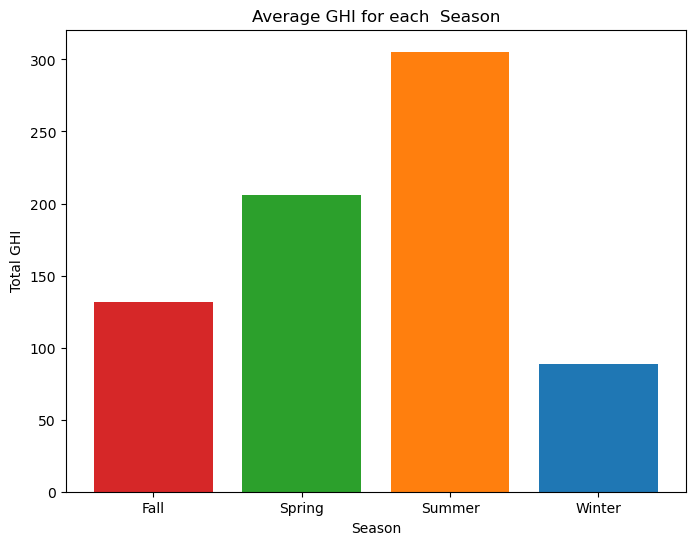

In [18]:

# Define colors for each season
season_colors = {
    'Winter': '#1f77b4',  # blue
    'Spring': '#2ca02c',  # green
    'Summer': '#ff7f0e',  # orange
    'Fall': '#d62728'     # red
}

# Total GHI per season
plt.figure(figsize=(8, 6))
plt.bar(seasonal_ghi_df['Season'], seasonal_ghi_df['GHI'],
        color=[season_colors[season] for season in seasonal_ghi_df['Season']])
plt.xlabel('Season')
plt.ylabel('Total GHI')
plt.title('Average GHI for each  Season')
plt.show()

In [20]:
!pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 1.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 867.2 kB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 830.0 kB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 830.0 kB/s eta 0:00:03
   --------------- ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## Performing ARIMA

In [21]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima
import matplotlib.pyplot as plt



target = data['GHI']

# Stationarity check and differencing if needed
# Differencing to remove trend if the series is non-stationary
target_diff = target.diff().dropna()

# Automatic order selection for ARIMA
auto_model = auto_arima(target_diff, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print("Optimal parameters (p, d, q):", auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=104241.335, Time=4.57 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=106383.769, Time=0.16 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=105029.072, Time=0.27 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=105412.797, Time=1.32 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=104728.858, Time=1.42 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=104781.716, Time=1.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=6.62 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=104059.688, Time=6.38 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=104588.494, Time=1.53 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=7.28 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=102511.252, Time=9.06 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=7.72 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=102501.011, Time=9.12 sec
 ARIMA(4,0,4)(0,0,0)[0]             : AIC=inf, Time=10.20 sec
 ARIMA(3,0,5)(0,0,0)[0]         

Training MAE: 63.93111516058034
Validation MAE: 185.60649839998436


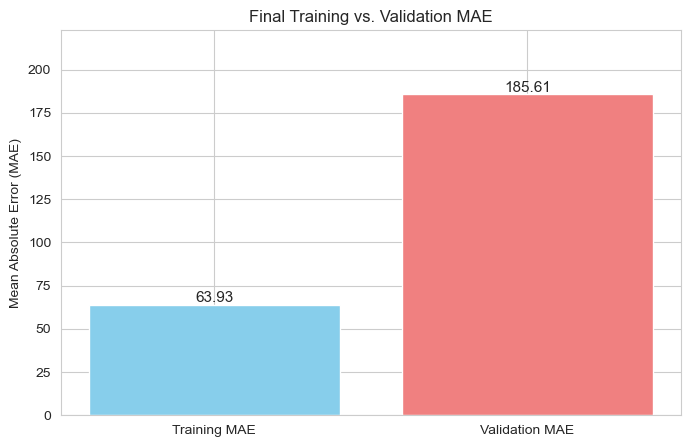

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# 1. Get Training Predictions (to calculate Training MAE)
# This gets the model's "fit" on the data it already saw
train_forecast = model_fit.fittedvalues

# 2. Calculate both MAEs
train_mae = mean_absolute_error(train, train_forecast)
test_mae = mean_absolute_error(test, forecast)

print(f"Training MAE: {train_mae}")
print(f"Validation MAE: {test_mae}")

# 3. Data for plotting
labels = ['Training MAE', 'Validation MAE']
values = [train_mae, test_mae]
colors = ['skyblue', 'lightcoral']

# 4. Create the plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid") # Matching the style in your image
bars = plt.bar(labels, values, color=colors)

# Add the numeric labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), 
             va='bottom', ha='center', fontsize=11)

plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Final Training vs. Validation MAE')
plt.ylim(0, max(values) * 1.2) # Give some space at the top for labels
plt.show()

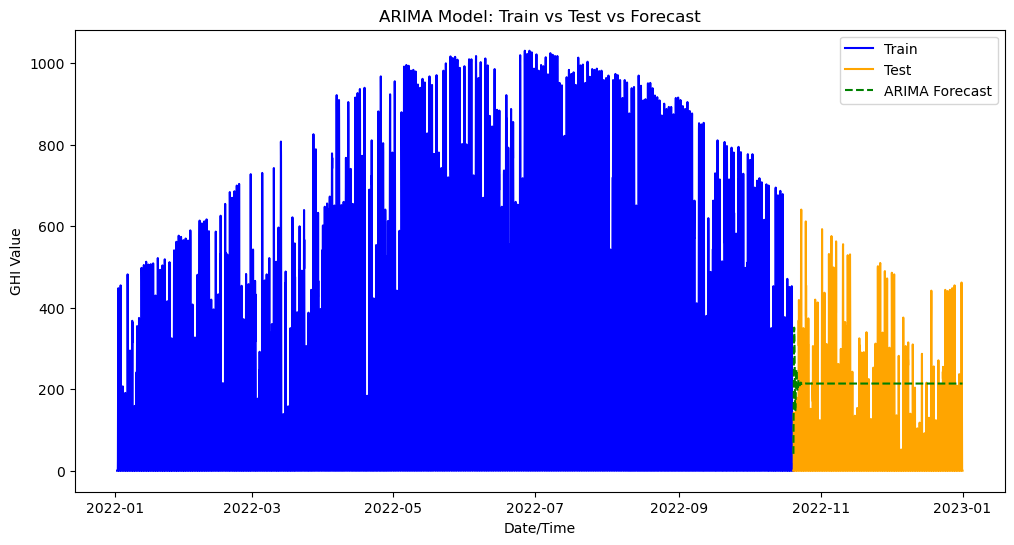

In [27]:
import matplotlib.pyplot as plt

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(train, label="Train", color='blue')
plt.plot(test, label="Test", color='orange')
plt.plot(forecast, label="ARIMA Forecast", color='green', linestyle='--')

plt.title("ARIMA Model: Train vs Test vs Forecast")
plt.xlabel("Date/Time")
plt.ylabel("GHI Value")
plt.legend()

plt.savefig('../../Outputs/arima.png', bbox_inches='tight', dpi=300)

# Now display to the screen
plt.show()

## Performing SARIMA

In [ ]:
auto_model = auto_arima(data['GHI'], 
                        seasonal=True, 
                        m=12, 
                        trace=True, # Prints out the combinations it tries
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)

print("\nBest Model Summary:")
print(auto_model.summary())

Performing stepwise search to minimize aic
